# Which behavioral and physiological factors most strongly predict sleep disorders?

## Task 5: Predictive Model or Insight Project 
### Goal:
- Build a simple predictive model or generate meaningful insights from data.
### Examples:
- Simple prediction using regression.
- Classification of data.
- Insight-based recommendation.
### Key Skills:
- Basic machine learning concepts, model understanding.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import shap
import json
import joblib

In [ ]:
data = pd.read_csv('data/data_preprocessed.csv')
data.head(3)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126,83,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0


In [82]:
le = LabelEncoder()
original_labels = data['Sleep Disorder']
le.fit(original_labels)

LabelEncoder()

In [83]:
data.shape

(374, 15)

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    object 
 12  Systolic_BP              374 non-null    int64  
 13  Diastolic_BP             374 non-null    int64  
 14  Sleep Disorder Encoded   3

In [85]:
categorical_columns = data.select_dtypes(include=['object']).columns
categorical_columns

Index(['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder'], dtype='object')

In [86]:
encoder = LabelEncoder()
for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])

In [87]:
data.head(3)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
0,1,1,27,9,6.1,6,42,6,3,77,4200,0,126,83,0
1,2,1,28,1,6.2,6,60,8,0,75,10000,0,125,80,0
2,3,1,28,1,6.2,6,60,8,0,75,10000,0,125,80,0


In [88]:
data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Systolic_BP', 'Diastolic_BP', 'Sleep Disorder Encoded'],
      dtype='object')

In [89]:
X = data.drop(columns=['Person ID','Sleep Disorder Encoded','Sleep Disorder'])
y = data['Sleep Disorder Encoded']

In [90]:
X.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Systolic_BP', 'Diastolic_BP'],
      dtype='object')

In [91]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.3, stratify=y, random_state=42)

Random Forest - ACC: 0.92
Random Forest Classification Report
 -               precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.83      0.83      0.83        23
 Sleep Apnea       0.82      0.96      0.88        24

    accuracy                           0.92       113
   macro avg       0.88      0.91      0.89       113
weighted avg       0.93      0.92      0.92       113



<Figure size 600x500 with 0 Axes>

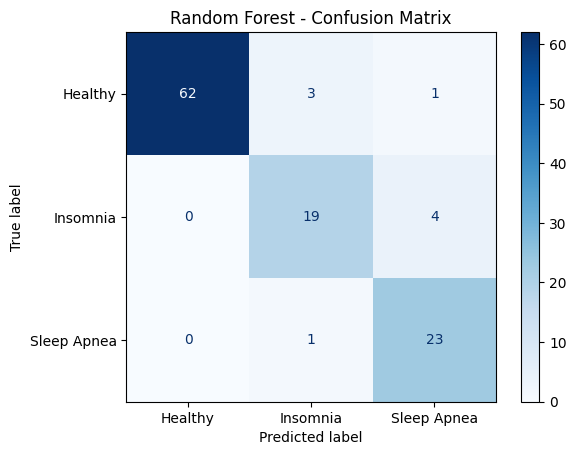

XGBoost - ACC: 0.90
XGBoost Classification Report
 -               precision    recall  f1-score   support

     Healthy       1.00      0.94      0.97        66
    Insomnia       0.76      0.83      0.79        23
 Sleep Apnea       0.81      0.88      0.84        24

    accuracy                           0.90       113
   macro avg       0.86      0.88      0.87       113
weighted avg       0.91      0.90      0.91       113



<Figure size 600x500 with 0 Axes>

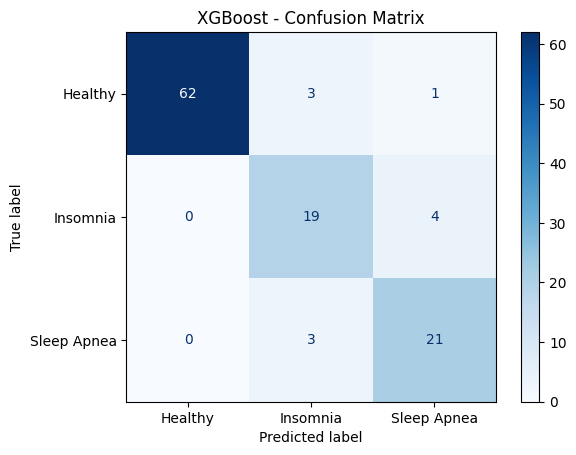

In [94]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42)}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    print(f"{name} - ACC: {acc:.2f}")
    y_test_labels = le.inverse_transform(y_test)
    pred_labels = le.inverse_transform(predictions)
    print(f"{name} Classification Report\n - {classification_report(y_test_labels, pred_labels)}")
    cm = confusion_matrix(y_test_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=le.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{name} - Confusion Matrix')
    plt.grid(False)
    plt.show()
    

SHAP summary plot


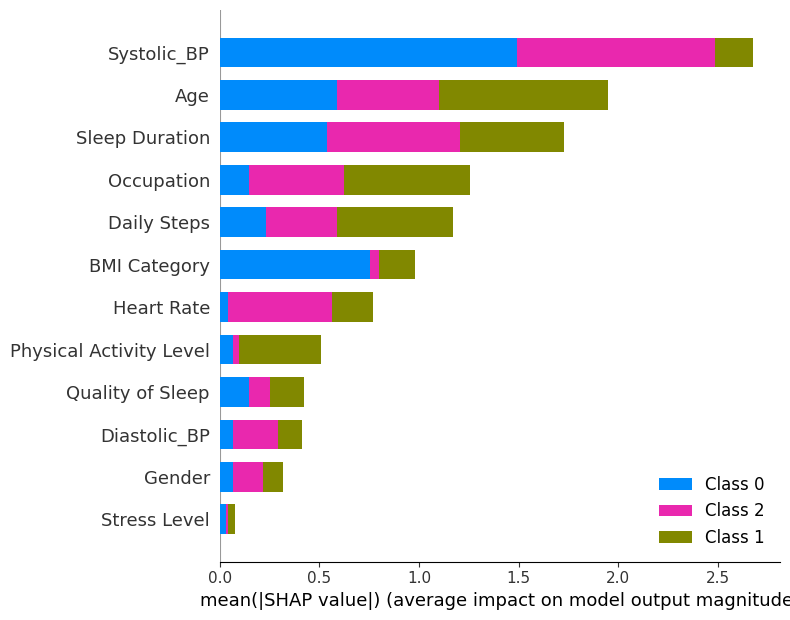

In [98]:
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test)
print("SHAP summary plot")
shap.summary_plot(shap_values,X_test,plot_type="bar")

SHAP summary plot


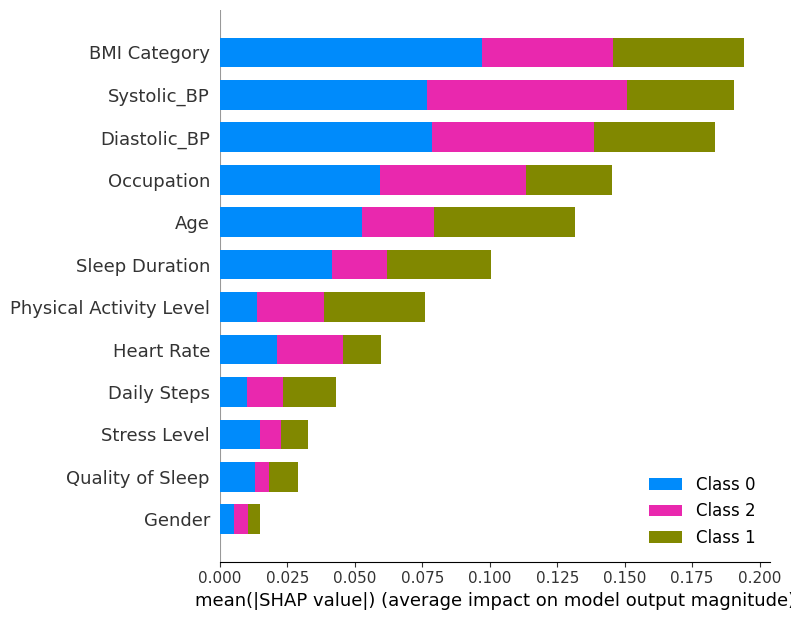

In [99]:
explainer = shap.TreeExplainer(models['Random Forest'])
shap_values = explainer.shap_values(X_test)
print("SHAP summary plot")
shap.summary_plot(shap_values,X_test,plot_type="bar")

Random Forest feature_importance


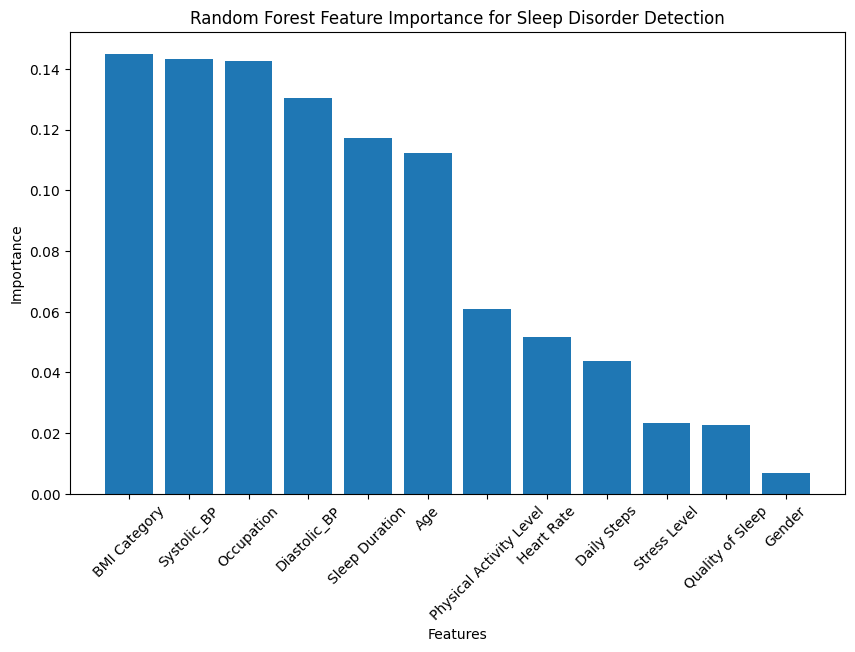

XGBoost feature_importance


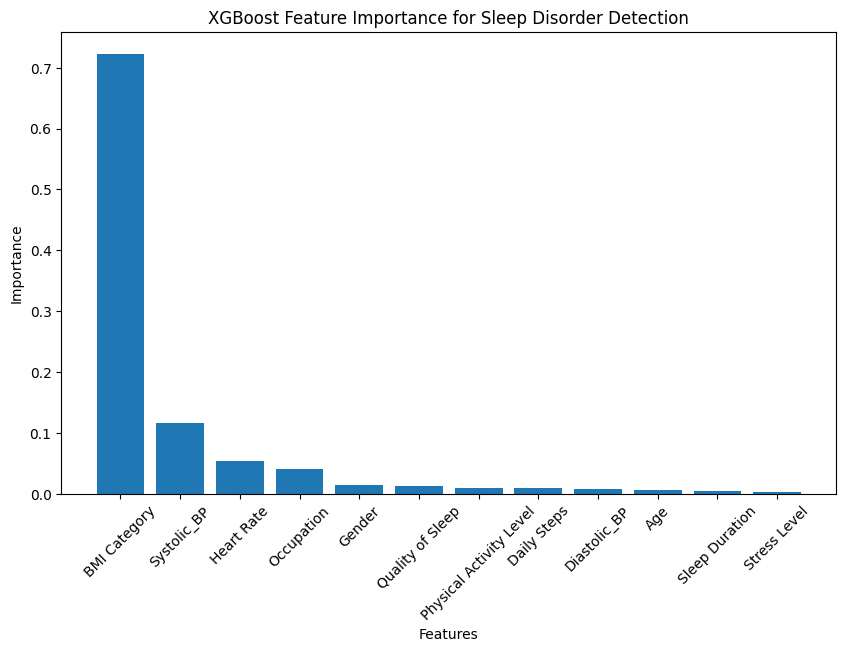

In [100]:
for name, model in models.items():
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': importance})
    feature_importance = feature_importance.sort_values( by='Importance', ascending=False)
    print(f'{name} feature_importance')
    plt.figure(figsize=(10,6))
    plt.bar(feature_importance['Feature'], feature_importance['Importance'])
    plt.xticks(rotation=45)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title(f'{name} Feature Importance for Sleep Disorder Detection')
    plt.show()

In [101]:
models['XGBoost'].save_model("models/xgboost_model.json")

In [ ]:
label_mapping = list(le.classes_)
with open('models/label_encoder.json', 'w') as f:
    json.dump(label_mapping, f)

In [ ]:
joblib.dump(models['Random Forest'], 'models/random_forest_model.joblib')

['models/random_forest_model.joblib']